In [1]:
# Preliminary features & parameters
import src.simulations.backtest_portfolio_v2 as bp
from src import indicators

features = {
        'sma_trend_regime': {
            'func': indicators.calculate_sma_crossover,
            'params': {'fast_window': 10, 'slow_window': 30, 'binary': True},
        },
        'sma_position': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 25},
        },
        'rsi': {
            'func': indicators.calculate_rsi,
            'params': {'window': 14},
        },
        'bollinger_position': {
            'func': indicators.calculate_bollinger_position,
            'params': {'window': 20, 'num_std': 2},
        },
        'price_roc': {
            'func': indicators.calculate_roc,
            'params': {'window': 5}
        }
    }

ticker_pool = [
        "NVDA", "MSFT", "AVGO", "NOW",
        "ORCL", "AAPL", "TEAM", "INTC",
        "SNOW", "WIX",  "AMD",  "CSCO",
        "SHOP", "AMZN", "CRM",
    ]
 
benchmark = "SPY"

/Users/jasonshi/Desktop/Python/finance_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
# Functionize model testing & plotting
import src.stock_screener as sc
import matplotlib.pyplot as plt
import seaborn as sns

def run_with_model(input_model, features_dict):
    engine = bp.PortfolioBacktestEngine(
        model=input_model,
        feature_configs=features_dict,
        confidence_threshold=0.60,
        bear_confidence_threshold=0.75,
        stop_loss=0.10,
        min_hold_days=7,
        adx_threshold=20,
        training_years=2,
        testing_years=1,
        offset_years=0
    )

    total_years = engine.training_years + engine.testing_years + engine.offset_years
    print(f"Downloading {total_years}y of data for {len(ticker_pool)} tickers + {benchmark}...")
    master_df = sc.fetch_screener_data(
        ticker_pool + [benchmark], period=f"{total_years}y", interval="1d"
    )
    print("Download Complete.")

    benchmark_prices = master_df['Close'][benchmark]
    benchmark_prices.name = benchmark

    engine.run_simulation(
        ticker_pool=ticker_pool,
        pre_downloaded_df=master_df,
        benchmark_prices=benchmark_prices,
    )

    print("\nTrade Log:")
    print(engine.last_trade_log.to_string(index=False))
    return engine, benchmark_prices

def plot_results(engine, benchmark_prices):
    sns.set_theme(style='darkgrid')
    bench = benchmark_prices.loc[engine.last_equity_curve.index]
    bench = bench / bench.iloc[0] * 10_000

    plt.figure(figsize=(12, 5))
    plt.plot(engine.last_equity_curve, label='Strategy', color='#2ecc71', linewidth=2)
    plt.plot(bench, label='Benchmark', color='#3498db', linewidth=2, linestyle='--')
    plt.title(f"Strategy {engine.last_strategy_return:+.2f}% | SPY {engine.last_benchmark_return:+.2f}% | Alpha {engine.last_alpha:+.2f}%", fontsize=13)
    plt.ylabel('Portfolio Value')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-23
  Test window  : 2025-06-23 to 2026-06-23
  Strategy Return   : +9.97%
  Benchmark (SPY) : +17.04%
  Alpha             : -7.08%
  Win Rate          : 59.38%
  Total Trades      : 32

Trade Log:
     type ticker      price       date     return
      BUY    WIX 150.500000 2025-07-28        NaN
STOP_LOSS    WIX 128.970001 2025-08-01 -14.305647
      BUY   AAPL 201.580307 2025-08-01        NaN
     SELL   AAPL 229.002121 2025-08-12  13.603419
      BUY    NOW 170.686005 2025-08-12        NaN
     SELL    NOW 175.393997 2025-08-21   2.758277
      BUY   ORCL 231.334503 2025-08-21        NaN
     SELL   ORCL 221.254028 2025-09-04  -4.357532
      BUY   NVDA 171.431671 2025-09-04        NaN
     SELL   NVDA 177.523575 2025-09-15   3.553546
      BUY    CRM 240.484589 2025-09-15        NaN
     SELL    CRM 244.250900 2025-09-24   1.566134
      BUY   SHOP 143.449997 2025-09-25        NaN
     SELL   SHO

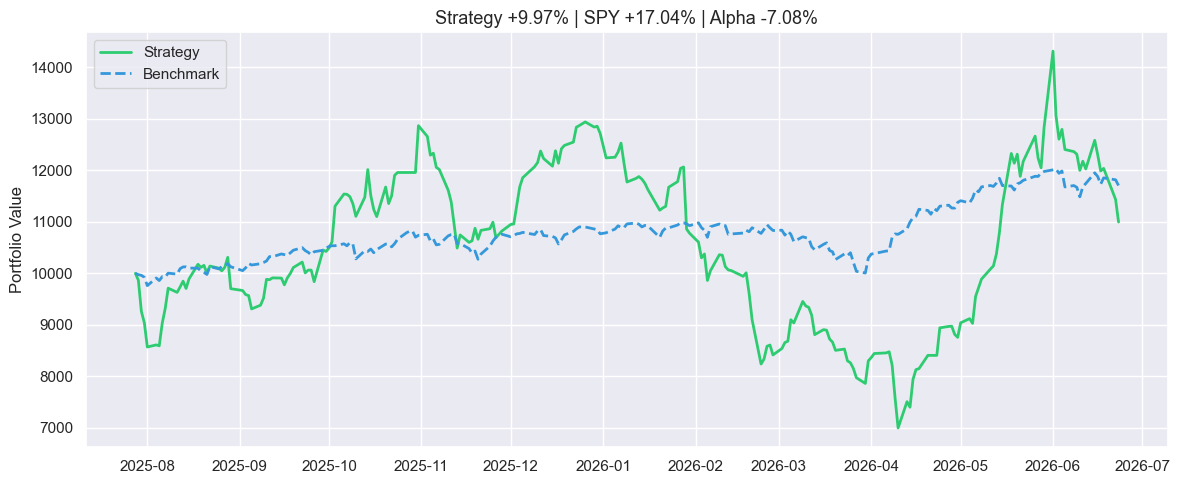

In [7]:
from sklearn import ensemble
rf_classifier = ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        min_samples_split=10,
        max_features='sqrt',
        max_depth=10
    )
engine, benchmark_prices = run_with_model(input_model=rf_classifier, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-23
  Test window  : 2025-06-23 to 2026-06-23
  Strategy Return   : +14.60%
  Benchmark (SPY) : +17.06%
  Alpha             : -2.46%
  Win Rate          : 54.84%
  Total Trades      : 31

Trade Log:
     type ticker      price       date     return
      BUY   INTC  20.680000 2025-07-28        NaN
     SELL   INTC  20.410000 2025-08-06  -1.305611
      BUY    NOW 182.462006 2025-08-06        NaN
     SELL    NOW 173.447998 2025-08-15  -4.940211
      BUY   CSCO  65.099670 2025-08-15        NaN
     SELL   CSCO  67.253265 2025-08-26   3.308150
      BUY   ORCL 232.376266 2025-08-26        NaN
     SELL   ORCL 230.977310 2025-09-05  -0.602022
      BUY   NVDA 166.797852 2025-09-05        NaN
     SELL   NVDA 174.657257 2025-09-16   4.711935
      BUY    CRM 237.301529 2025-09-16        NaN
     SELL    CRM 239.343826 2025-09-25   0.860634
      BUY   SHOP 143.449997 2025-09-25        NaN
     SELL   SH

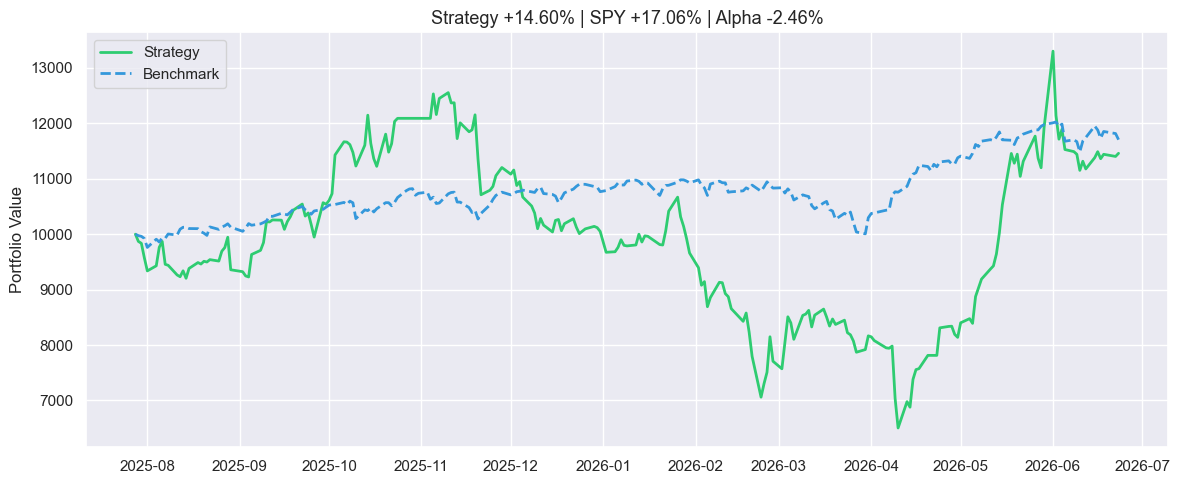

In [4]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05)

engine, benchmark_prices = run_with_model(input_model=xgb_model, features_dict=features)
plot_results(engine, benchmark_prices)

[                       0%                       ]

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-23
  Test window  : 2025-06-23 to 2026-06-23
  Strategy Return   : -11.80%
  Benchmark (SPY) : +17.06%
  Alpha             : -28.86%
  Win Rate          : 46.88%
  Total Trades      : 32

Trade Log:
     type ticker      price       date     return
      BUY   INTC  20.680000 2025-07-28        NaN
     SELL   INTC  20.410000 2025-08-06  -1.305611
      BUY    WIX 128.490005 2025-08-06        NaN
STOP_LOSS    WIX 115.430000 2025-08-11 -10.164219
      BUY   TEAM 159.279999 2025-08-11        NaN
     SELL   TEAM 166.550003 2025-08-20   4.564292
      BUY   ORCL 233.219589 2025-08-20        NaN
     SELL   ORCL 224.359528 2025-08-29  -3.799021
      BUY   NVDA 173.948303 2025-08-29        NaN
     SELL   NVDA 177.094147 2025-09-10   1.808493
      BUY   AAPL 226.150192 2025-09-10        NaN
     SELL   AAPL 244.807419 2025-09-19   8.249927
      BUY   SHOP 143.449997 2025-09-25        NaN
     SELL   S

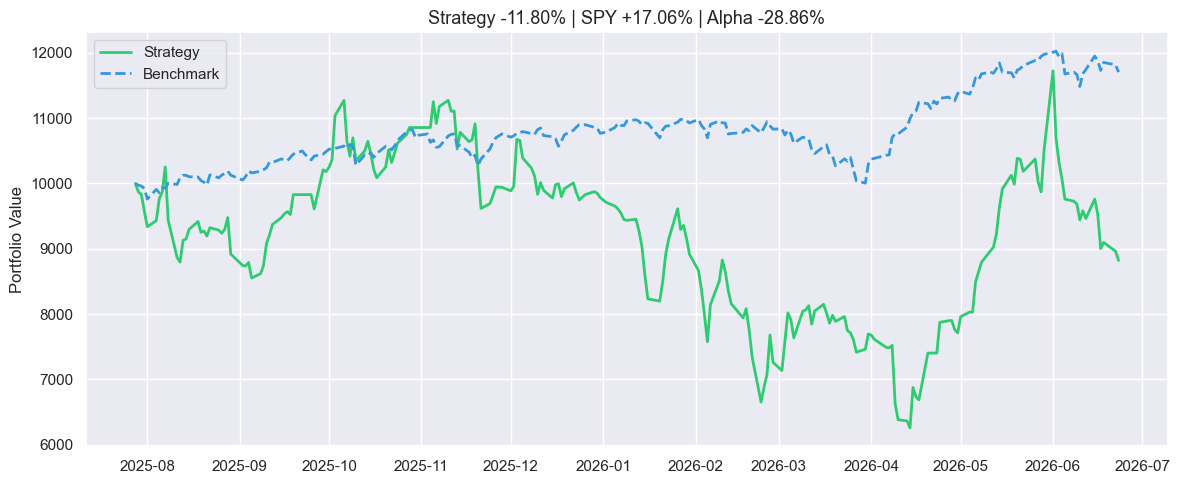

In [5]:
from sklearn.linear_model import LogisticRegression

# There was some noise based on dividing by 0, etc. that we filter out
import warnings
warnings.filterwarnings('ignore')

logreg_model = LogisticRegression(C=0.1)

engine, benchmark_prices = run_with_model(input_model=logreg_model, features_dict=features)
plot_results(engine, benchmark_prices)